In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
d0 = pd.read_csv(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\ROCKi_experiments\c3_actin_analysis_12G10_live_incubation\d0\test_outputs\actinupreg\acinar_results_membrane_upregulation.csv")

In [6]:
d7 = pd.read_csv(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\ROCKi_experiments\c3_actin_analysis_12G10_live_incubation\d7\test_outputs\integrinupreg\acinar_results_membrane_upregulation.csv")

In [27]:
df = pd.concat([d0, d7], ignore_index=True)

In [30]:
df.columns

Index(['acinus_volume_um3', 'acinus_roundness', 'membrane_edge_shell_median',
       'membrane_inner_shell_median', 'membrane_edge_to_inner_ratio',
       'edge_shell_volume_um3', 'inner_shell_volume_um3',
       'protein_exterior_shell_median', 'protein_to_membrane_edge_ratio',
       'protein_to_membrane_inner_ratio', 'exterior_shell_volume_um3', 'flag',
       'filename', 'well', 'day', 'cell_type', 'condition', 'treatment',
       'image_type'],
      dtype='str')

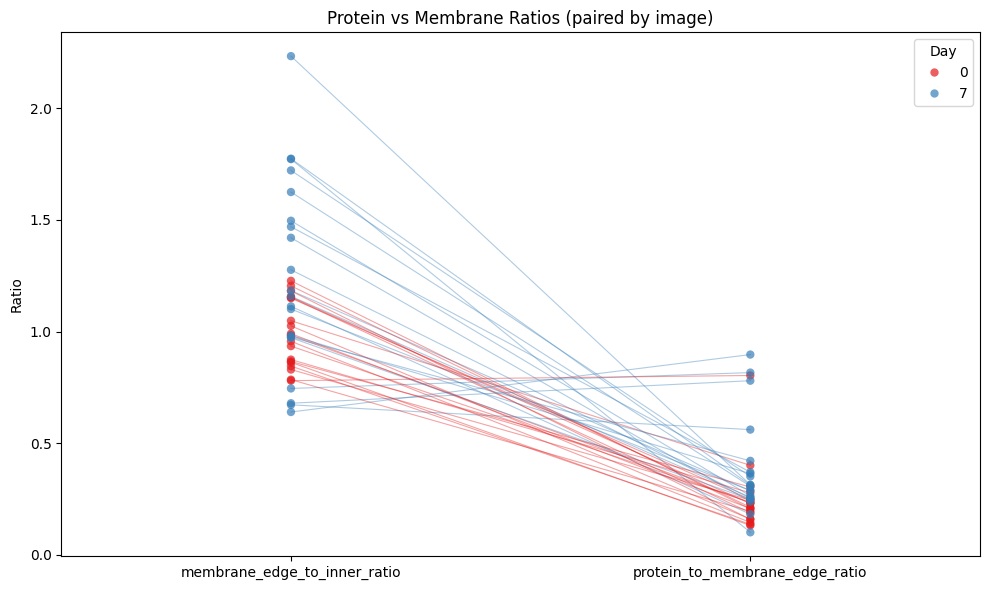

In [31]:

# Reshape so each image has one row per metric
plot_df = df[["filename", "day", "protein_to_membrane_edge_ratio", "membrane_edge_to_inner_ratio"]].copy()
plot_df = plot_df.melt(
    id_vars=["filename", "day"],
    value_vars=["protein_to_membrane_edge_ratio", "membrane_edge_to_inner_ratio"],
    var_name="metric",
    value_name="ratio",
)

fig, ax = plt.subplots(figsize=(10, 6))

palette = sns.color_palette("Set1", n_colors=df["day"].nunique())
day_colors = {d: palette[i] for i, d in enumerate(sorted(df["day"].unique()))}

# Draw lines connecting paired points for each image
for _, grp in plot_df.groupby("filename"):
    if len(grp) == 2:
        row = grp.sort_values("metric")
        ax.plot(
            row["metric"].values,
            row["ratio"].values,
            color=day_colors[row["day"].iloc[0]],
            alpha=0.4,
            linewidth=0.8,
        )

# Draw dots
sns.stripplot(
    data=plot_df,
    x="metric",
    y="ratio",
    hue="day",
    palette=day_colors,
    dodge=False,
    jitter=False,
    size=6,
    alpha=0.7,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Ratio")
ax.set_title("Protein vs Membrane Ratios (paired by image)")
ax.legend(title="Day")
plt.tight_layout()
plt.show()


In [23]:
df.columns

Index(['acinus_volume_um3', 'acinus_roundness', 'membrane_edge_shell_median',
       'membrane_inner_shell_median', 'membrane_edge_to_inner_ratio',
       'edge_shell_volume_um3', 'inner_shell_volume_um3',
       'protein_exterior_shell_median', 'protein_to_membrane_edge_ratio',
       'protein_to_membrane_inner_ratio', 'exterior_shell_volume_um3', 'flag',
       'filename', 'well', 'day', 'cell_type', 'condition', 'treatment',
       'image_type'],
      dtype='str')

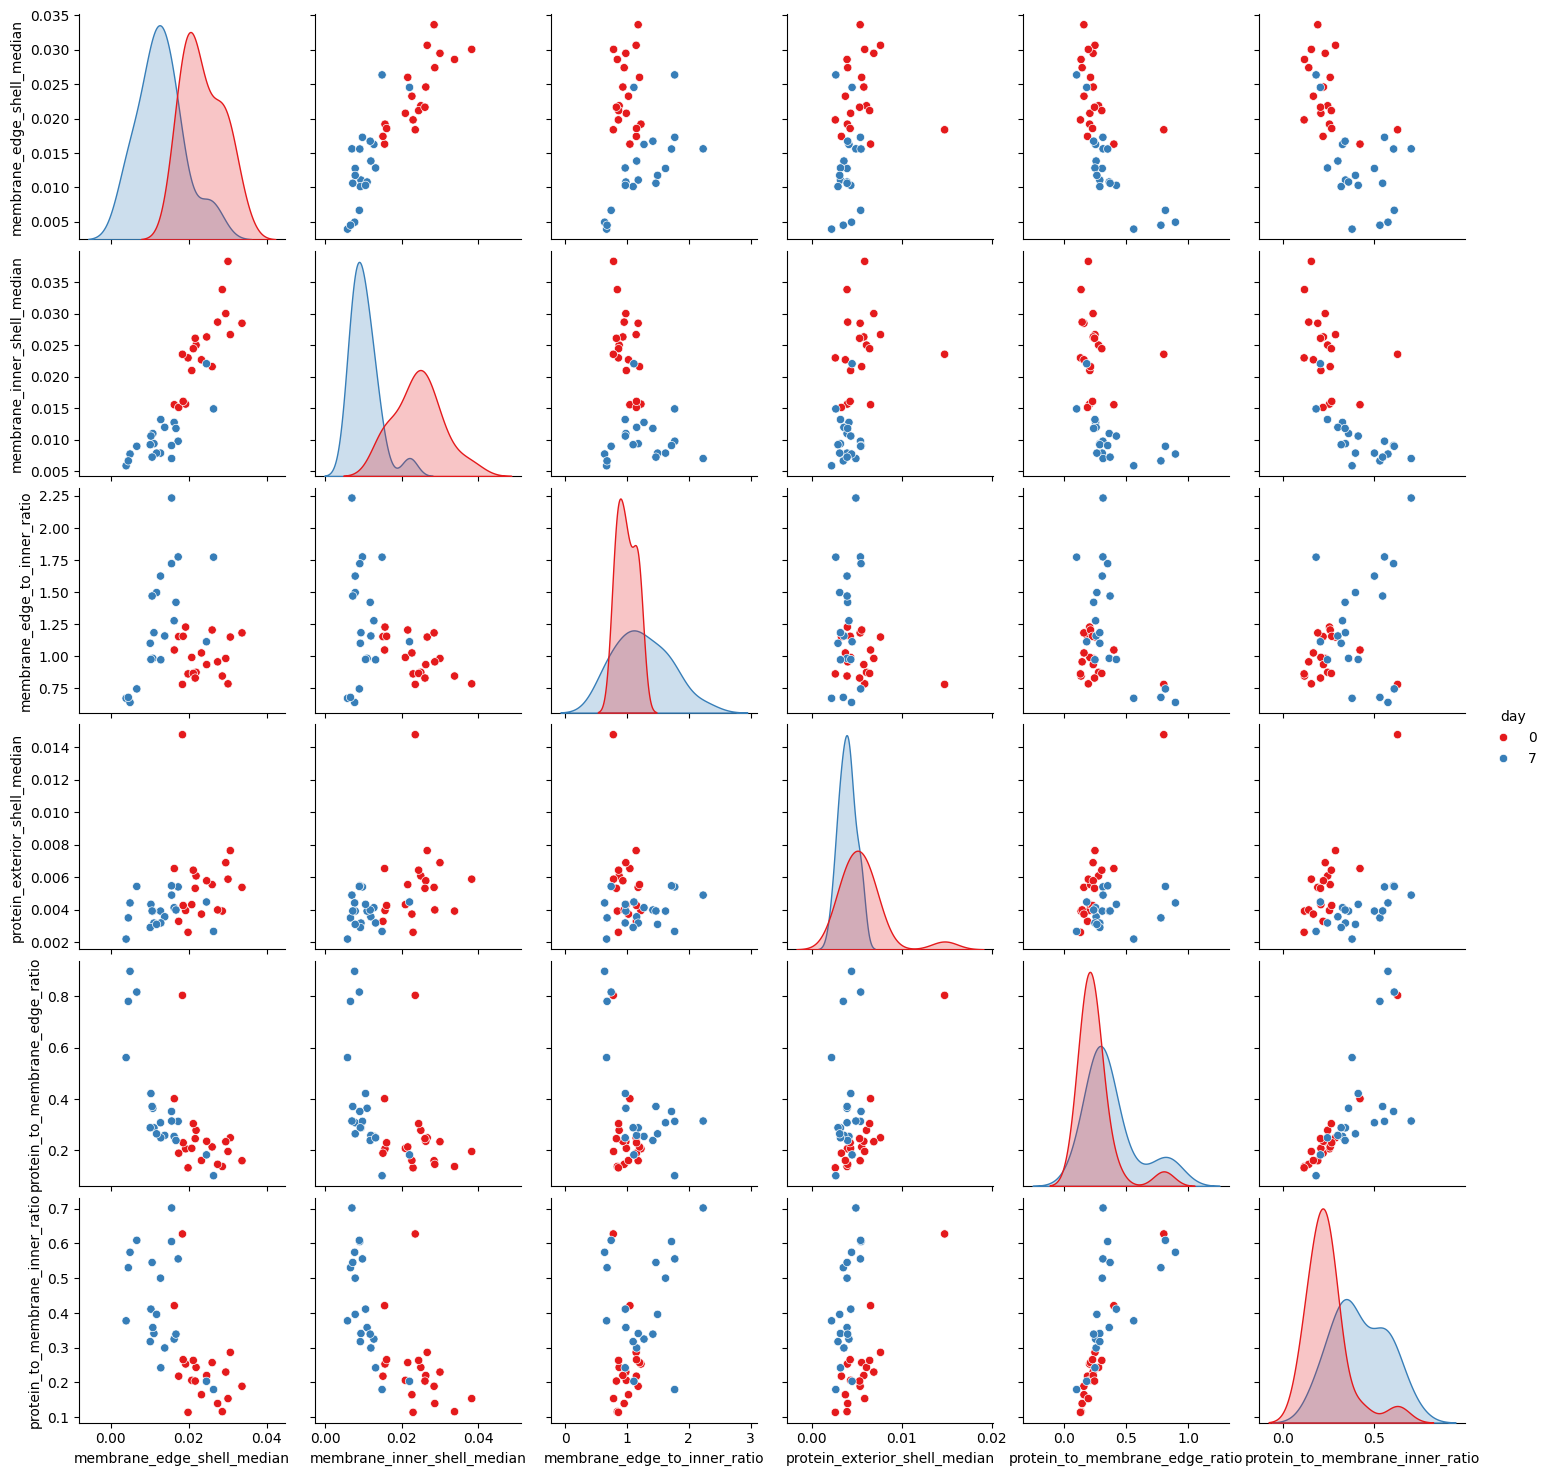

In [25]:
sns.pairplot(data=df, vars=['membrane_edge_shell_median',
       'membrane_inner_shell_median', 'membrane_edge_to_inner_ratio',
       'protein_exterior_shell_median', 'protein_to_membrane_edge_ratio',
       'protein_to_membrane_inner_ratio'], hue="day", palette=day_colors)

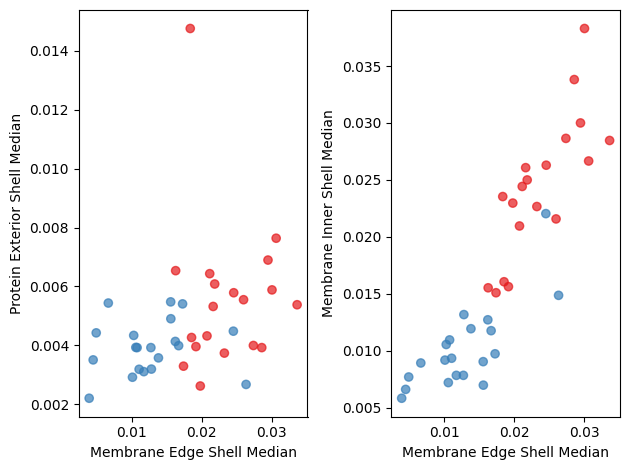

In [19]:
fig, ax = plt.subplots(ncols = 2)

ax[0].scatter(df["membrane_edge_shell_median"], df["protein_exterior_shell_median"], c=df["day"].map(day_colors), alpha=0.7)
ax[0].set_xlabel("Membrane Edge Shell Median")
ax[0].set_ylabel("Protein Exterior Shell Median")

ax[1].scatter(df["membrane_edge_shell_median"], df["membrane_inner_shell_median"], c=df["day"].map(day_colors), alpha=0.7)
ax[1].set_xlabel("Membrane Edge Shell Median")
ax[1].set_ylabel("Membrane Inner Shell Median")
plt.tight_layout()